In [78]:
# uv 프로젝트 환경이 있으면 uv sync로 의존성 설치 (권장)
!pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels pingouin scikit_posthocs xgboost -q
print("pip 설치 완료!")

pip 설치 완료!


In [79]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)



라이브러리 로드 완료!
한글 폰트 설정 완료!


In [80]:
df_origin_meta = pd.read_csv('metadata.csv')
df_meta = df_origin_meta.copy()

In [81]:
df_meta.columns

Index(['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id',
       'uid', 'filename', 'Capacity', 'Re', 'Rct'],
      dtype='str')

In [82]:
df_meta.info()

<class 'pandas.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   type                 7565 non-null   str  
 1   start_time           7565 non-null   str  
 2   ambient_temperature  7565 non-null   int64
 3   battery_id           7565 non-null   str  
 4   test_id              7565 non-null   int64
 5   uid                  7565 non-null   int64
 6   filename             7565 non-null   str  
 7   Capacity             2794 non-null   str  
 8   Re                   1956 non-null   str  
 9   Rct                  1956 non-null   str  
dtypes: int64(3), str(7)
memory usage: 1.3 MB


In [83]:
def clear_time(x):
    # 사용할 리스트
    nums = []
    # 임시 저장용
    current = ''

    # 반복문으로 숫자만 뽑아내기
    for ch in x:
        if ch.isdigit() or ch in ['.', '_' 'e', 'E', '+']:  # '_' 제거
            current += ch
        else:
            if current != '':
                nums.append(current)
                current = ''

    # 숫자 남아있을 수도 있으니 한번 더 리스트에 append
    if current != '':
        nums.append(current)

    # 연월일시분초 하면 최소 6자리, 그 이하는 버림
    if len(nums) < 6:
        return None

    # nums 리스트 숫자형으로 변환, 앞에 6개만 변환
    try:
        nums = list(map(float, nums[:6]))
    except:
        return None

    # 각 숫자에 의미 부여
    year, month, day, hour, minute, second = nums

    # 이상치 제거
    if not (2000 <= year and 1 <= month <= 12 and 1 <= day <= 31 and
            0 <= hour < 24 and 0 <= minute < 60 and 0 <= second < 60):
        return None

    # Timestamp로 변환
    return pd.Timestamp(
        int(year), int(month), int(day),
        int(hour), int(minute), int(second)
    )

df_meta['start_time'] = df_meta['start_time'].apply(clear_time)
df_meta = df_meta.dropna(subset=['start_time'])
df_meta = df_meta.sort_values(['battery_id', 'start_time']).reset_index(drop=True)

In [84]:
# # 1. 파일 위치
# metadata_file = "./metadata.csv"
data_folder = "./data"

# # 2. metadata 불러오기
# df = pd.read_csv(metadata_file)

# 3. 컬럼명 공백 제거
df_meta.columns = df_meta.columns.str.strip()

# 4. filename 컬럼 공백 제거
df_meta["filename"] = df_meta["filename"].astype(str).str.strip()

# 5. metadata의 각 파일을 읽어서 합치기
all_data = []

df_meta = df_meta.reset_index(drop=True)

for i in range(len(df_meta)):
    file_name = df_meta.loc[i, "filename"] #metadata의 i번째 행에서 "filename" 값을 가져옴
    file_path = data_folder + "/" + file_name #7000개 csv파일 경로 만들기
    data_df = pd.read_csv(file_path)

    data_df["filename"] = file_name #00001.csv를 읽었으면 그 파일의 모든 행에 "00001.csv"를 붙임
    data_df["type"] = df_meta.loc[i, "type"] #metadata의 i번째 행에 적힌 type 값을 지금 파일의 모든 행에 붙임
    data_df["battery_id"] = df_meta.loc[i, "battery_id"] #metadata의 i번째 행에 적힌 battery_id를 지금 파일의 모든 행에 붙임
    data_df["start_time"] = df_meta.loc[i, "start_time"] #metadata의 i번째 행에 적힌 start_time를 지금 파일의 모든 행에 붙임
    
    all_data.append(data_df) #만든 data_df를 all_data 리스트에 넣음

# 6. 전체 파일 합치기
full_data = pd.concat(all_data, ignore_index=True) #all_data 안에 들어 있는 여러 데이터프레임을 세로 방향으로 하나로 이어붙임
#7.csv파일로 저장
#full_data.to_csv("full_data.csv", index=False)

In [85]:
df_meta.head(10)

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,2008-04-03 04:16:37,24,B0005,7,5128,05128.csv,1.8352625275821128,NaN,NaN
1,charge,2008-04-03 05:27:49,24,B0005,8,5129,05129.csv,NaN,NaN,NaN
2,discharge,2008-04-03 08:33:25,24,B0005,9,5130,05130.csv,1.8346455082120419,NaN,NaN
3,charge,2008-04-03 09:44:35,24,B0005,10,5131,05131.csv,NaN,NaN,NaN
4,discharge,2008-04-03 12:55:10,24,B0005,11,5132,05132.csv,1.8356616600675495,NaN,NaN
5,charge,2008-04-03 14:06:43,24,B0005,12,5133,05133.csv,NaN,NaN,NaN
6,discharge,2008-04-03 17:17:16,24,B0005,13,5134,05134.csv,1.8351461429226603,NaN,NaN
7,charge,2008-04-03 18:28:47,24,B0005,14,5135,05135.csv,NaN,NaN,NaN
8,discharge,2008-04-03 21:28:14,24,B0005,15,5136,05136.csv,1.8257567905665537,NaN,NaN
9,charge,2008-04-03 22:38:27,24,B0005,16,5137,05137.csv,NaN,NaN,NaN


In [86]:
df_meta = df_meta.sort_values(['battery_id', 'start_time']).reset_index(drop=True)

df_meta['cycle'] = (
    df_meta.groupby('battery_id')['type']
    .transform(lambda x: (x.str.lower() == 'discharge').cumsum())
)

# 확인
discharge_cycles = df_meta[df_meta['type'].str.lower() == 'discharge']
print(discharge_cycles[['battery_id', 'cycle', 'Capacity']].head(10))

   battery_id  cycle            Capacity
0       B0005      1  1.8352625275821128
2       B0005      2  1.8346455082120419
4       B0005      3  1.8356616600675495
6       B0005      4  1.8351461429226603
8       B0005      5  1.8257567905665537
10      B0005      6   1.824613268496936
11      B0005      7  1.8246195526864504
14      B0005      8  1.8142019357673917
19      B0005      9    1.80210690024615
21      B0005     10   1.802579500826209


In [87]:
charge_df = df_meta[df_meta['type'].str.lower() == 'charge']
file_charge = charge_df['filename'].astype(str).tolist()

discharge_df = df_meta[df_meta['type'].str.lower() == 'discharge']
file_discharge = discharge_df['filename'].astype(str).tolist()

impedance_df = df_meta[df_meta['type'].str.lower() == 'impedance']
file_impedance = impedance_df['filename'].astype(str).tolist()

print(file_charge)
print(file_discharge)
print(file_impedance)

['05129.csv', '05131.csv', '05133.csv', '05135.csv', '05137.csv', '05143.csv', '05144.csv', '05146.csv', '05148.csv', '05150.csv', '05152.csv', '05154.csv', '05156.csv', '05158.csv', '05160.csv', '05164.csv', '05168.csv', '05172.csv', '05176.csv', '05180.csv', '05188.csv', '05192.csv', '05196.csv', '05200.csv', '05204.csv', '05205.csv', '05208.csv', '05212.csv', '05220.csv', '05224.csv', '05228.csv', '05232.csv', '05236.csv', '05240.csv', '05244.csv', '05248.csv', '05252.csv', '05258.csv', '05266.csv', '05269.csv', '05272.csv', '05276.csv', '05280.csv', '05284.csv', '05288.csv', '05292.csv', '05296.csv', '05300.csv', '05338.csv', '05342.csv', '05346.csv', '05350.csv', '05354.csv', '05362.csv', '05366.csv', '05370.csv', '05382.csv', '05385.csv', '05388.csv', '05392.csv', '05400.csv', '05404.csv', '05408.csv', '05412.csv', '05416.csv', '05420.csv', '05424.csv', '05428.csv', '05435.csv', '05446.csv', '05450.csv', '05454.csv', '05458.csv', '05462.csv', '05466.csv', '05470.csv', '05474.csv'

In [88]:
df_meta['battery_id'].nunique()
df_meta['battery_id'].unique()
#38,39,40 -> 
#41~44

<ArrowStringArray>
['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028',
 'B0029', 'B0030', 'B0031', 'B0032', 'B0033', 'B0034', 'B0036', 'B0038',
 'B0039', 'B0040', 'B0041', 'B0042', 'B0043', 'B0044', 'B0045', 'B0046',
 'B0047', 'B0048', 'B0049', 'B0050', 'B0051', 'B0052', 'B0053', 'B0054',
 'B0055', 'B0056']
Length: 34, dtype: str

In [89]:
battery_05_18 = df_meta[df_meta['battery_id'].isin(['B0005', 'B0006', 'B0007', 'B0018'])]
battery_25_28 = df_meta[df_meta['battery_id'].isin(['B0025', 'B0026', 'B0027', 'B0028'])]
battery_29_32 = df_meta[df_meta['battery_id'].isin(['B0029', 'B0030', 'B0031', 'B0032'])]
battery_33_36 = df_meta[df_meta['battery_id'].isin(['B0033', 'B0034', 'B0036'])]
battery_38_40 = df_meta[df_meta['battery_id'].isin(['B0038', 'B0039', 'B0040'])]
battery_41_44 = df_meta[df_meta['battery_id'].isin(['B0041', 'B0042', 'B0043', 'B0044'])]
battery_45_48 = df_meta[df_meta['battery_id'].isin(['B0045', 'B0046', 'B0047', 'B0048'])]
battery_49_52 = df_meta[df_meta['battery_id'].isin(['B0049', 'B0050', 'B0051', 'B0052'])]
battery_53_56 = df_meta[df_meta['battery_id'].isin(['B0053', 'B0054', 'B0055', 'B0056'])]

In [90]:
battery_groups = {
    '05_18': battery_05_18,
    '25_28': battery_25_28,
    '29_32': battery_29_32,
    '33_36': battery_33_36,
    '38_40': battery_38_40,
    '41_44': battery_41_44,
    '45_48': battery_45_48,
    '49_52': battery_49_52,
    '53_56': battery_53_56,
}

In [91]:
cycle_summary = (
    df_meta[df_meta['type'].str.lower() == 'discharge']
    .groupby('battery_id')['cycle']
    .max()
    .reset_index()
    .rename(columns={'cycle': 'total_cycles'})
)
print(cycle_summary)



   battery_id  total_cycles
0       B0005           126
1       B0006           126
2       B0007           126
3       B0018           104
4       B0025             8
5       B0026             8
6       B0027             8
7       B0028             8
8       B0029            34
9       B0030            34
10      B0031            34
11      B0032            34
12      B0033           151
13      B0034           151
14      B0036           151
15      B0038            38
16      B0039            38
17      B0040            38
18      B0041            57
19      B0042            95
20      B0043            95
21      B0044            95
22      B0045            59
23      B0046            59
24      B0047            59
25      B0048            59
26      B0049            23
27      B0050            23
28      B0051            23
29      B0052            23
30      B0053            53
31      B0054            97
32      B0055            96
33      B0056            96


In [92]:
for group_name, group_df in battery_groups.items():
    summary = (
        group_df[group_df['type'].str.lower() == 'discharge']
        .groupby('battery_id')['cycle']
        .max()
        .reset_index()
        .rename(columns={'cycle': 'total_cycles'})
    )
    print(f"--- {group_name} ---")
    print(summary)

--- 05_18 ---
  battery_id  total_cycles
0      B0005           126
1      B0006           126
2      B0007           126
3      B0018           104
--- 25_28 ---
  battery_id  total_cycles
0      B0025             8
1      B0026             8
2      B0027             8
3      B0028             8
--- 29_32 ---
  battery_id  total_cycles
0      B0029            34
1      B0030            34
2      B0031            34
3      B0032            34
--- 33_36 ---
  battery_id  total_cycles
0      B0033           151
1      B0034           151
2      B0036           151
--- 38_40 ---
  battery_id  total_cycles
0      B0038            38
1      B0039            38
2      B0040            38
--- 41_44 ---
  battery_id  total_cycles
0      B0041            57
1      B0042            95
2      B0043            95
3      B0044            95
--- 45_48 ---
  battery_id  total_cycles
0      B0045            59
1      B0046            59
2      B0047            59
3      B0048            59
--- 49_52 -

In [93]:
print(df_meta['ambient_temperature'].unique())
print(df_meta.groupby(['battery_id', 'ambient_temperature']).size().reset_index().rename(columns={0: 'count'}))

[24 43 44  4 22]
   battery_id  ambient_temperature  count
0       B0005                   24    479
1       B0006                   24    479
2       B0007                   24    479
3       B0018                   24    255
4       B0025                   24     26
5       B0026                   24     26
6       B0027                   24     26
7       B0028                   24     26
8       B0029                   43     80
9       B0030                   43     80
10      B0031                   43     80
11      B0032                   43     80
12      B0033                   24    384
13      B0034                   24    384
14      B0036                   24    384
15      B0038                   24     45
16      B0038                   44     59
17      B0039                   24     45
18      B0039                   44     59
19      B0040                   24     45
20      B0040                   44     59
21      B0041                    4    110
22      B0041    

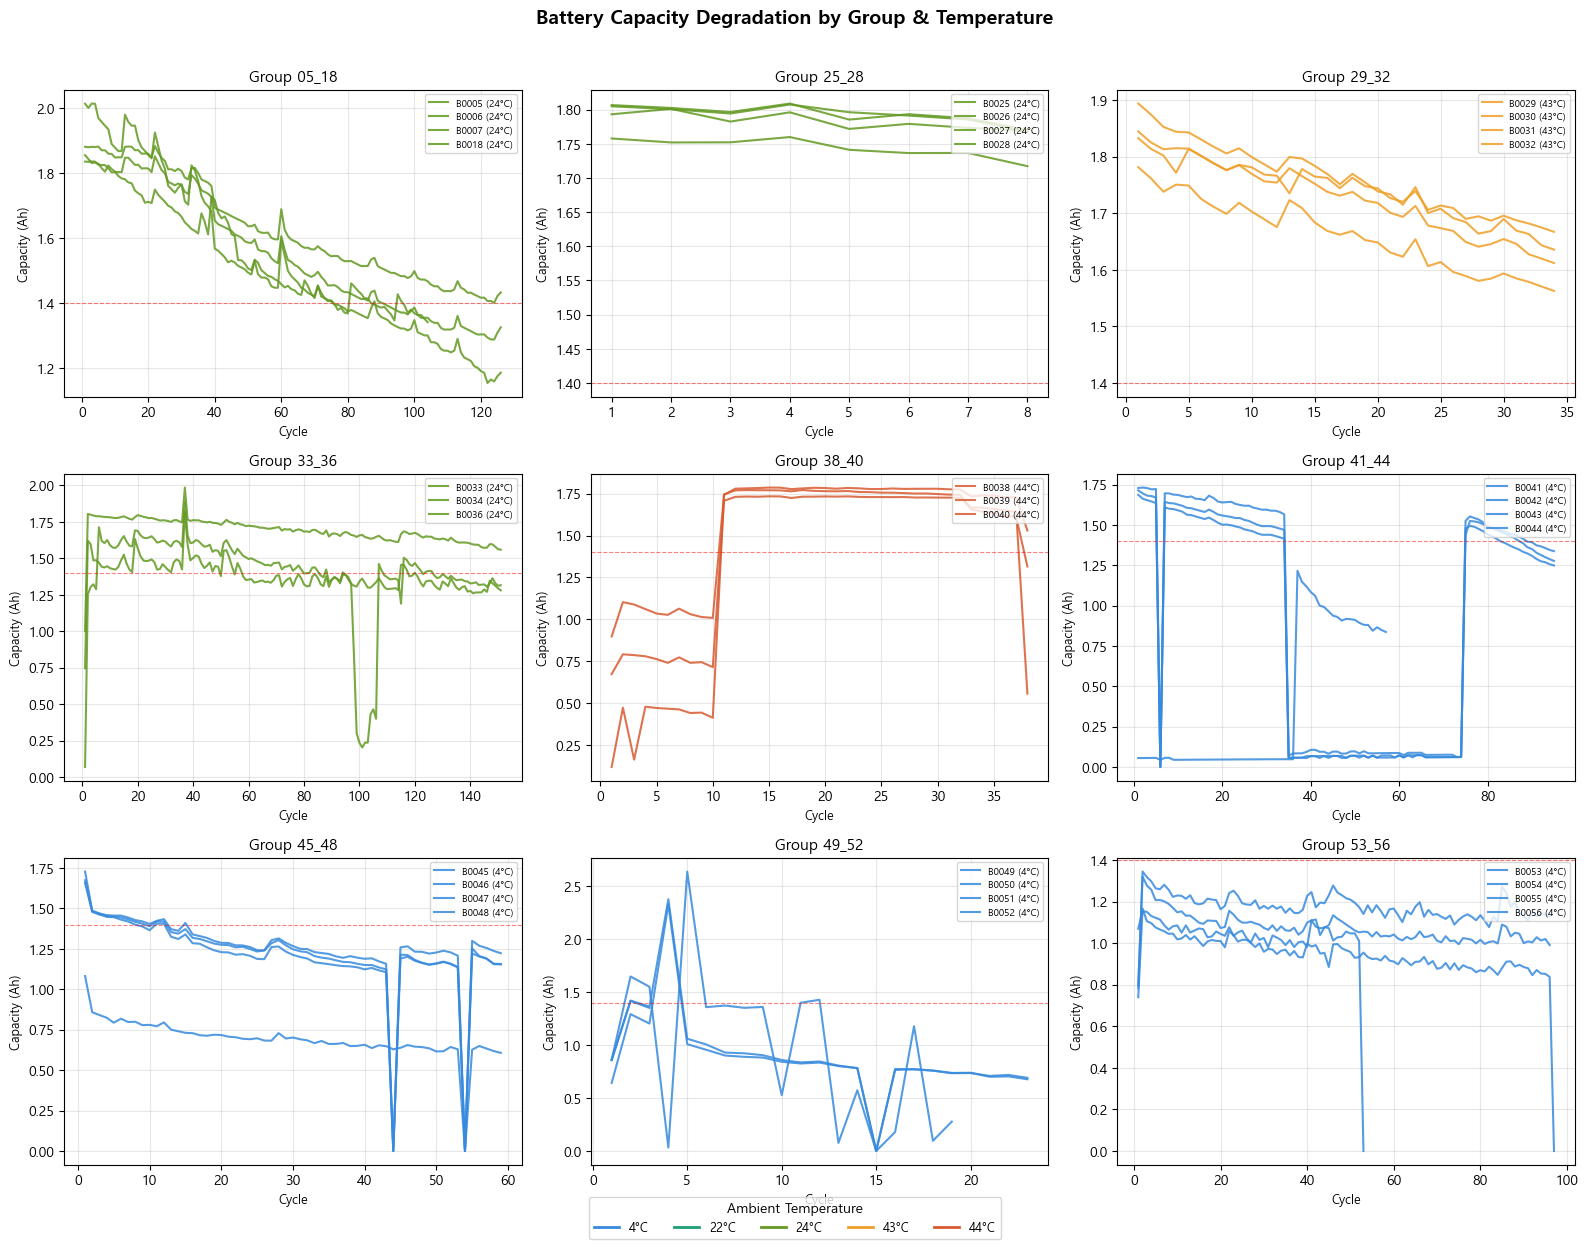

In [94]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# 온도별 색상 매핑
temp_colors = {4: '#378ADD', 22: '#1D9E75', 24: '#639922', 43: '#EF9F27', 44: '#D85A30'}

# discharge 기준으로 필터링
discharge_meta = df_meta[df_meta['type'].str.lower() == 'discharge'].copy()
discharge_meta['Capacity'] = pd.to_numeric(discharge_meta['Capacity'], errors='coerce')
discharge_meta['ambient_temperature'] = pd.to_numeric(discharge_meta['ambient_temperature'], errors='coerce')

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, (group_name, group_df) in enumerate(battery_groups.items()):
    ax = axes[idx]
    
    battery_ids = group_df['battery_id'].unique()
    
    for battery_id in battery_ids:
        bat_data = discharge_meta[discharge_meta['battery_id'] == battery_id].sort_values('cycle')
        temp = bat_data['ambient_temperature'].mode()[0]  # 해당 배터리의 대표 온도
        color = temp_colors.get(int(temp), 'gray')
        
        ax.plot(bat_data['cycle'], bat_data['Capacity'],
                label=f"{battery_id} ({int(temp)}°C)",
                color=color, linewidth=1.5, alpha=0.85)
    
    ax.set_title(f"Group {group_name}", fontsize=11)
    ax.set_xlabel("Cycle", fontsize=9)
    ax.set_ylabel("Capacity (Ah)", fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=1.4, color='red', linestyle='--', linewidth=0.8, alpha=0.5)  # EOL 기준선 (70% of 2Ah)

# 온도 범례 (전체 공통)
legend_elements = [plt.Line2D([0], [0], color=c, linewidth=2, label=f'{t}°C')
                   for t, c in temp_colors.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=5,
           title='Ambient Temperature', fontsize=9, title_fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle("Battery Capacity Degradation by Group & Temperature", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('capacity_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

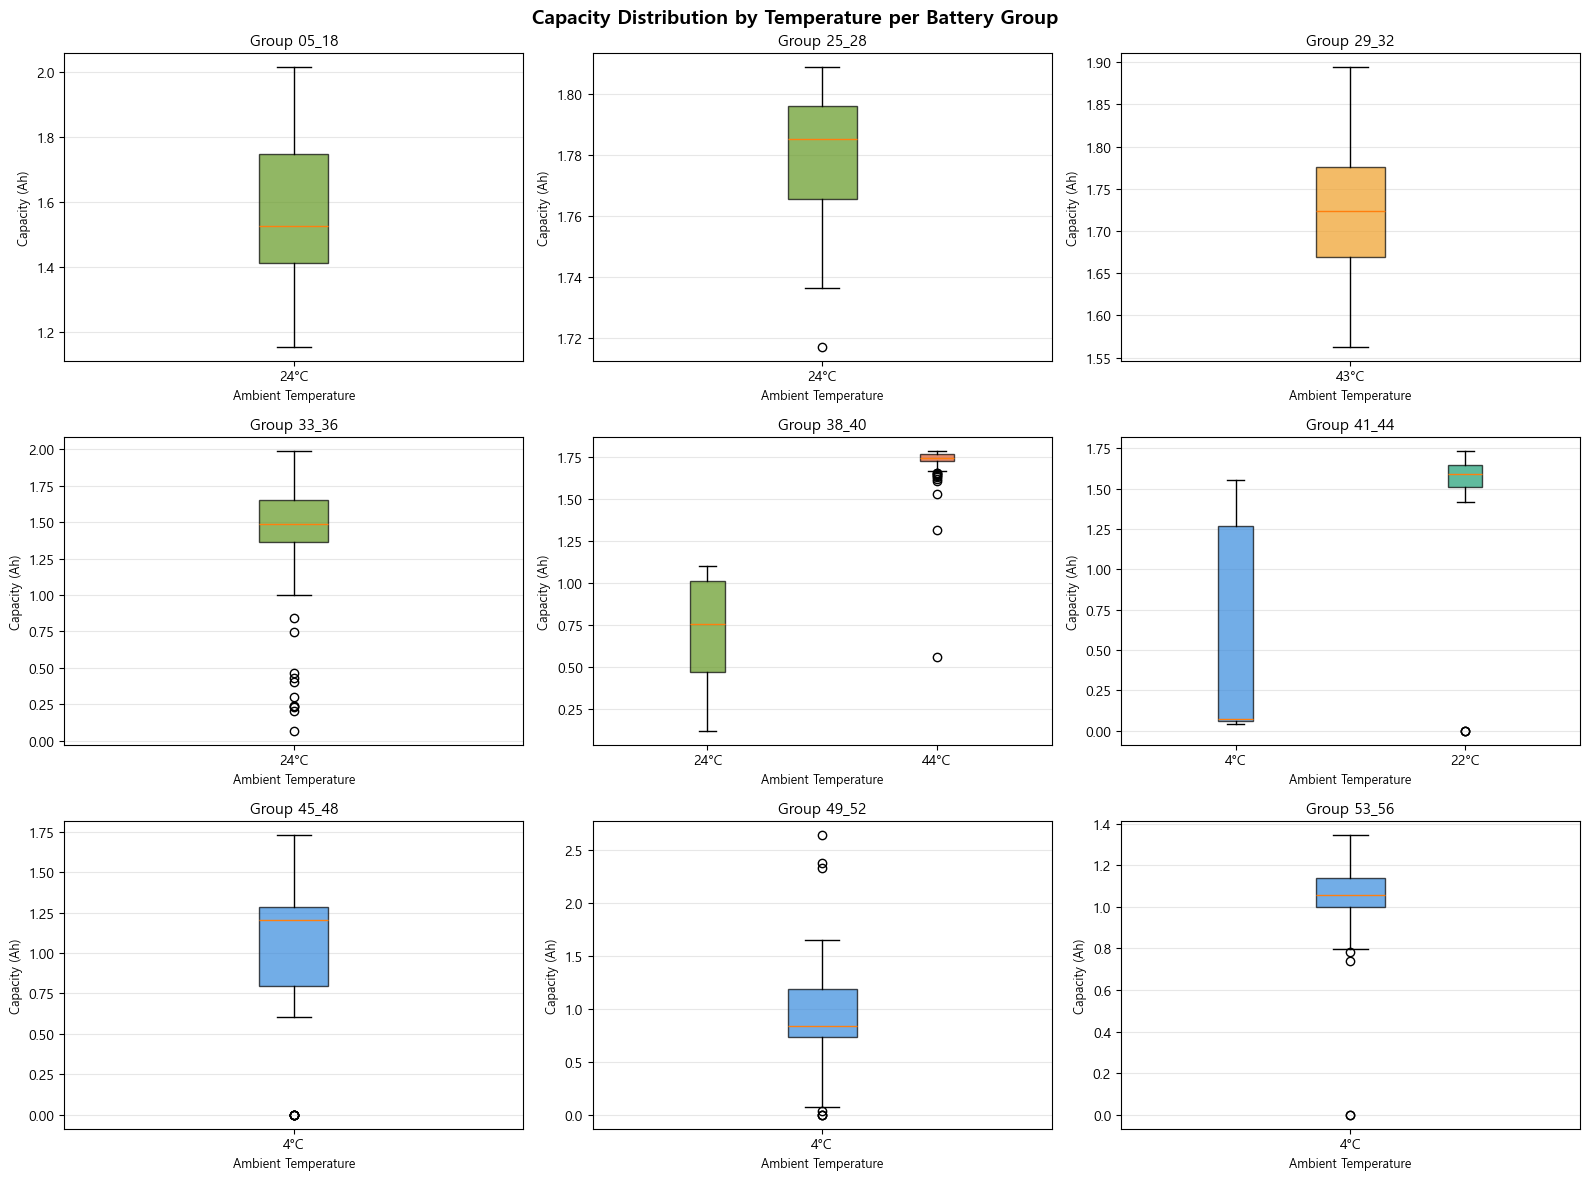

In [95]:
import matplotlib.pyplot as plt
import numpy as np

discharge_meta = df_meta[df_meta['type'].str.lower() == 'discharge'].copy()
discharge_meta['Capacity'] = pd.to_numeric(discharge_meta['Capacity'], errors='coerce')
discharge_meta['ambient_temperature'] = pd.to_numeric(discharge_meta['ambient_temperature'], errors='coerce')

temp_colors = {4: '#378ADD', 22: '#1D9E75', 24: '#639922', 43: '#EF9F27', 44: '#D85A30'}

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, (group_name, group_df) in enumerate(battery_groups.items()):
    ax = axes[idx]
    
    battery_ids = sorted(group_df['battery_id'].unique())
    bat_data = discharge_meta[discharge_meta['battery_id'].isin(battery_ids)]
    
    temps = sorted(bat_data['ambient_temperature'].unique())
    
    # 온도별로 박스플롯
    plot_data = [bat_data[bat_data['ambient_temperature'] == t]['Capacity'].dropna() for t in temps]
    colors = [temp_colors.get(int(t), 'gray') for t in temps]
    
    bp = ax.boxplot(plot_data, patch_artist=True, labels=[f"{int(t)}°C" for t in temps])
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(f"Group {group_name}", fontsize=11)
    ax.set_xlabel("Ambient Temperature", fontsize=9)
    ax.set_ylabel("Capacity (Ah)", fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle("Capacity Distribution by Temperature per Battery Group", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('capacity_by_temperature.png', dpi=150, bbox_inches='tight')
plt.show()